Some weights of the model checkpoint at C:\Users\moham\Desktop\checkpoints\checkpoint-120000 were not used when initializing BertModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


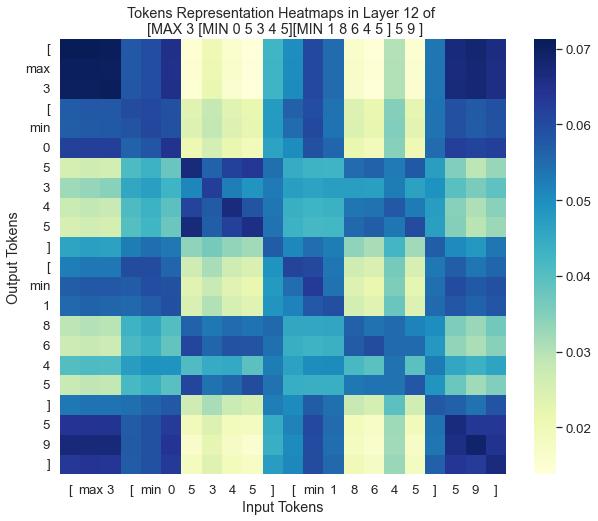

In [20]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, BertModel


def create_representation_heatmap(model, tokenizer, sequence):

    # Tokenize the input text
    observed_layer = 12
    inputs = tokenizer(sequence, return_tensors="pt", add_special_tokens=True)
    input_ids = inputs["input_ids"]
    tokens = [tokenizer.convert_ids_to_tokens(i) for i in input_ids][0]

    # Get the model outputs
    with torch.no_grad():
        outputs = model(**inputs)
        attentions = outputs[-1]

    # Retrieve the hidden states from the outputs
    hidden_states = outputs.hidden_states

    # Access hidden state

    last_hidden_state = hidden_states[observed_layer]

    # Compute the representations by multiplying  hidden state with its transpose
    representations = torch.matmul(last_hidden_state, last_hidden_state.transpose(-1, -2))

    # Convert the representations to a NumPy array
    representations = representations[0].detach().numpy()

    # Remove the special tokens from the representations matrix
    representations = representations[1:-1, 1:-1]

    # Normalize the remaining representations
    representations = representations / representations.sum(axis=1, keepdims=True)

    # Set the size of the figure
    plt.figure(figsize=(10, 8))

    # Plot the representations as a heatmap
    sns.set(font_scale=1.2)
    ax = sns.heatmap(representations, cmap="YlGnBu",
                 xticklabels=tokenizer.convert_ids_to_tokens(input_ids[0])[1:-1],
                 yticklabels=tokenizer.convert_ids_to_tokens(input_ids[0])[1:-1])
    plt.xlabel("Input Tokens")
    plt.ylabel("Output Tokens")
    plt.title(f"Tokens Representation Heatmaps in Layer {observed_layer} of \n {sequence}")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.show()


# Load the pre-trained model and tokenizer
model_name = r"C:\Users\moham\Desktop\checkpoints\checkpoint-120000"
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained(model_name, output_hidden_states=True)

# Input sequence
sequence = "[MAX 3 [MIN 0 5 3 4 5][MIN 1 8 6 4 5 ] 5 9 ]"

create_representation_heatmap(model, tokenizer, sequence)
